# 02 — Retention fit

Fit a parametric retention curve `retention(τ)` such that:

```
excess_NP(t) ⊛ retention(τ) ≈ observed_DAU_lift(d)
```

where `⊛` is causal convolution, both sides are marketing-attributable excess (= 2026 minus 52w-aligned 2025 minus pre-campaign baseline YoY), and the retention curve is fitted to the data rather than imported from elsewhere — guaranteeing the fit matches by construction.

Inputs are the parquets written by `01_signal_extraction.ipynb` into `data/`.

## Milestones
- **M1 (this notebook so far)**: load cached signals, derive `excess_NP(t)` and `observed_DAU_lift(d)`, plot both for visual validation.
- **M2**: define convolution + 3-param fast/slow retention, fit with `scipy.optimize`, plot fit.
- **M3**: residual diagnostics, retention shape sanity, in-sample-vs-holdout test.


In [ ]:
# [setup]
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Windows — must match 01_signal_extraction's choices so the YoY baseline
# subtraction is consistent.
BASELINE_START = pd.Timestamp('2026-02-01')
BASELINE_END = pd.Timestamp('2026-03-28')     # 8 weeks pre-campaign
CAMPAIGN_LAUNCH = pd.Timestamp('2026-04-06')  # Adjust ACI new-profile spike

# Easter mask. The 52w-aligned YoY comparison is broken near Easter because the
# holiday drifts ~2 weeks year-over-year:
#   2026 Easter Sunday = Apr 5  → real DAU dip in 2026 actuals
#   2025 Easter Sunday = Apr 20 → 52w-shifted lands on Apr 19 in 2026 coords
# We mask a 5-day window centered on each (-2..+2 days), in 2026 coordinates.
EASTER_2026 = pd.Timestamp('2026-04-05')
EASTER_2025_ALIGNED = pd.Timestamp('2026-04-18')  # nudged back 1d from naive 52w shift to match observed artifact center
EASTER_MASK_DATES = pd.DatetimeIndex(sorted({
    *(EASTER_2026 + pd.Timedelta(days=d) for d in (-2, -1, 0, 1, 2)),
    *(EASTER_2025_ALIGNED + pd.Timedelta(days=d) for d in (-2, -1, 0, 1, 2)),
}))

DATA_DIR = Path('data')
assert DATA_DIR.exists(), f"Run 01_signal_extraction.ipynb first; expected cached parquets in {DATA_DIR.resolve()}"

# Plot palette
NP_COLOR = 'C2'         # green — acquisition flow
DAU_COLOR = 'C3'        # red — DAU lift
BASELINE_BAND_COLOR = 'lightyellow'
MASKED_COLOR = '0.6'    # mid grey for Easter-masked points


In [37]:
# [load-signals]
# Load cached 2026 + 52w-aligned 2025 series from 01_signal_extraction.
new_profiles_2026 = pd.read_parquet(DATA_DIR / 'new_profiles_2026.parquet')
new_profiles_2025_aligned = pd.read_parquet(DATA_DIR / 'new_profiles_2025_aligned.parquet')
dau_2026 = pd.read_parquet(DATA_DIR / 'dau_2026.parquet')
dau_2025_aligned = pd.read_parquet(DATA_DIR / 'dau_2025_aligned.parquet')

# Align on the 2026 date index used by both DataFrames; only dates present in
# both YoY pairs survive (other-year-only rows drop out).
np_index = new_profiles_2026.index.intersection(new_profiles_2025_aligned.index)
dau_index = dau_2026.index.intersection(dau_2025_aligned.index)

# Per-bucket YoY differences (2026 minus 52w-aligned 2025)
np_yoy = new_profiles_2026.loc[np_index] - new_profiles_2025_aligned.loc[np_index]
dau_yoy = dau_2026.loc[dau_index] - dau_2025_aligned.loc[dau_index]

# Baseline YoY: the natural seasonal/trend offset captured in the pre-campaign
# window. Subtracting this off the YoY series gives the marketing-attributable
# excess (= 0 in the baseline window by construction).
np_baseline_mask = (np_yoy.index >= BASELINE_START) & (np_yoy.index <= BASELINE_END)
dau_baseline_mask = (dau_yoy.index >= BASELINE_START) & (dau_yoy.index <= BASELINE_END)
np_yoy_baseline_offset = np_yoy.loc[np_baseline_mask, 'total_new_profiles'].mean()
dau_yoy_baseline_offset = dau_yoy.loc[dau_baseline_mask, 'total_dau'].mean()

# The two series the convolution operates on
excess_NP = (np_yoy['total_new_profiles'] - np_yoy_baseline_offset).rename('excess_NP')
observed_DAU_lift = (dau_yoy['total_dau'] - dau_yoy_baseline_offset).rename('observed_DAU_lift')

# Sanity prints
print(f'excess_NP:        {len(excess_NP)} days, '
      f'{excess_NP.index.min().date()} to {excess_NP.index.max().date()}')
print(f'observed_DAU_lift: {len(observed_DAU_lift)} days, '
      f'{observed_DAU_lift.index.min().date()} to {observed_DAU_lift.index.max().date()}')
print(f'Baseline YoY offsets subtracted (the structural-trend term):')
print(f'  total new profiles: {np_yoy_baseline_offset:>+12,.0f} / day')
print(f'  total DAU:          {dau_yoy_baseline_offset:>+12,.0f} / day')

# In-window mean of each series — should be ~0 in baseline, positive post-campaign.
post_mask = excess_NP.index >= CAMPAIGN_LAUNCH
print(f'\nSanity check:')
print(f'  excess_NP  in baseline window:        {excess_NP.loc[np_baseline_mask].mean():>+12,.0f} / day  (should be ~0)')
print(f'  excess_NP  in post-campaign window:   {excess_NP.loc[post_mask].mean():>+12,.0f} / day')
print(f'  DAU lift   in baseline window:        {observed_DAU_lift.loc[dau_baseline_mask].mean():>+12,.0f} / day  (should be ~0)')
print(f'  DAU lift   in post-campaign window:   {observed_DAU_lift.loc[post_mask].mean():>+12,.0f} / day')


excess_NP:        105 days, 2026-02-01 to 2026-05-16
observed_DAU_lift: 105 days, 2026-02-01 to 2026-05-16
Baseline YoY offsets subtracted (the structural-trend term):
  total new profiles:     -108,507 / day
  total DAU:            +1,049,841 / day

Sanity check:
  excess_NP  in baseline window:                  -0 / day  (should be ~0)
  excess_NP  in post-campaign window:       +108,471 / day
  DAU lift   in baseline window:                  -0 / day  (should be ~0)
  DAU lift   in post-campaign window:       +363,042 / day


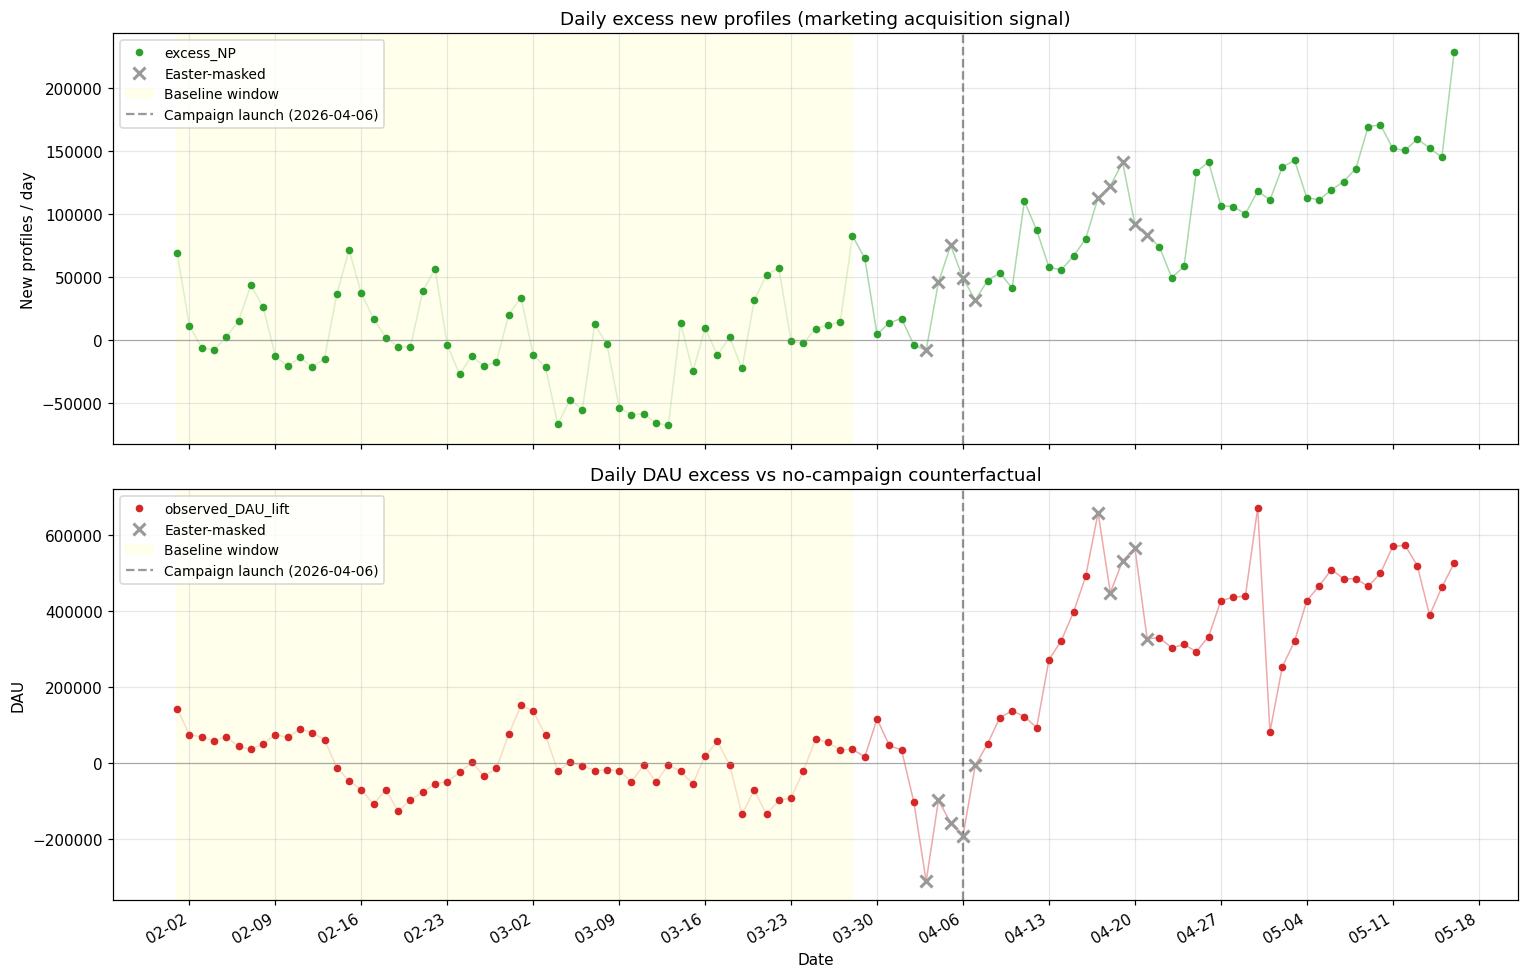

Easter-masked dates (10): 04-03, 04-04, 04-05, 04-06, 04-07, 04-17, 04-18, 04-19, 04-20, 04-21


In [38]:
# [plot-signals]
# Visual validation. Two panels: NP excess (the acquisition input) and DAU lift
# (the response). Easter-masked points are drawn in grey so we can see what's
# being excluded from the M2 fit.

fig, (ax_np, ax_dau) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)


def _plot_with_mask(ax, series, color, label):
    mask = series.index.isin(EASTER_MASK_DATES)
    ax.plot(series.index, series, '-', linewidth=1.0, color=color, alpha=0.4, zorder=1)
    ax.plot(series.index[~mask], series[~mask], 'o', markersize=4, color=color, label=label, zorder=2)
    ax.plot(series.index[mask], series[mask], 'x', markersize=8, color=MASKED_COLOR,
            markeredgewidth=2, label='Easter-masked', zorder=3)
    ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
    ax.axvspan(BASELINE_START, BASELINE_END, color=BASELINE_BAND_COLOR, alpha=0.6, label='Baseline window')
    ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4, label=f'Campaign launch ({CAMPAIGN_LAUNCH.date()})')


_plot_with_mask(ax_np, excess_NP, NP_COLOR, 'excess_NP')
ax_np.set_title('Daily excess new profiles (marketing acquisition signal)')
ax_np.set_ylabel('New profiles / day')
ax_np.legend(fontsize=9, loc='upper left')

_plot_with_mask(ax_dau, observed_DAU_lift, DAU_COLOR, 'observed_DAU_lift')
ax_dau.set_title('Daily DAU excess vs no-campaign counterfactual')
ax_dau.set_ylabel('DAU')
ax_dau.set_xlabel('Date')
ax_dau.legend(fontsize=9, loc='upper left')
ax_dau.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax_dau.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f'Easter-masked dates ({len(EASTER_MASK_DATES)}): '
      f'{", ".join(d.strftime("%m-%d") for d in EASTER_MASK_DATES)}')


In [ ]:
# [retention-fit]
from scipy.optimize import minimize

# Align both series on a common daily index. Both should already share dates
# from load-signals, but we re-intersect defensively and reindex to a
# gap-free daily range so the convolution stays well-defined.
common_index = pd.date_range(
    max(excess_NP.index.min(), observed_DAU_lift.index.min()),
    min(excess_NP.index.max(), observed_DAU_lift.index.max()),
    freq='D',
)
np_series = excess_NP.reindex(common_index, fill_value=0.0)
dau_series = observed_DAU_lift.reindex(common_index, fill_value=0.0)
n_days = len(common_index)

# Loss mask: every date EXCEPT the Easter-corrupted ones.
fit_mask = ~common_index.isin(EASTER_MASK_DATES)

# Loss-component normalization scale.
DAU_LIFT_SCALE = 400_000

# Empirical integrated retention (user-days of DAU lift per excess NP), computed
# directly from the post-campaign cumulative ratio. This is what the model's
# integrated retention should target — important because the final 28-day MA
# projection is dominated by integrated quantities.
post_mask = (common_index >= CAMPAIGN_LAUNCH) & fit_mask
TARGET_INTEGRATED_RETENTION = (
    dau_series.values[post_mask].sum() / np_series.values[post_mask].sum()
)

# Loss weights:
#   REG_WEIGHT — soft floor on τ_slow (keeps long tail plausible)
#   INTEGRAL_WEIGHT — pulls the model's integrated retention to empirical.
#     Set high enough to essentially pin the integral; the convolution term
#     then determines the curve SHAPE under that integral constraint.
#   SHAPE_ANCHOR_WEIGHT — single D1 anchor at a plausible mobile-paid value.
#     With integral pinned, this shape anchor redistributes mass away from
#     τ=0 toward the longer tail without changing the integrated retention.
TAU_SLOW_FLOOR = 20.0
REG_WEIGHT = 0.001
INTEGRAL_WEIGHT = 5.0
SHAPE_ANCHOR_D1 = 0.30
SHAPE_ANCHOR_WEIGHT = 0.5

HISTORICAL_RETENTION_REFERENCE = {1: 0.256, 3: 0.170, 7: 0.139, 14: 0.116, 28: 0.100}


def retention(tau, a, tau_fast, tau_slow):
    """Two-component exponential retention. retention(0) == 1.0 by construction."""
    return a * np.exp(-tau / tau_fast) + (1.0 - a) * np.exp(-tau / tau_slow)


def integrated_retention(a, tau_fast, tau_slow):
    """Lifetime user-days per acquisition (integral of retention over τ)."""
    return a * tau_fast + (1.0 - a) * tau_slow


def predict_dau_lift(np_values, a, tau_fast, tau_slow):
    """Causal convolution: predicted_lift[d] = Σ_{t≤d} np_values[t] · retention(d-t)."""
    lags = np.arange(n_days)
    kernel = retention(lags, a, tau_fast, tau_slow)
    full_conv = np.convolve(np_values, kernel, mode='full')
    return full_conv[:n_days]


def loss(params):
    a, tau_fast, tau_slow = params

    # Convolution-fit term (per-day MSE), normalized.
    predicted = predict_dau_lift(np_series.values, *params)
    conv_residuals = (predicted - dau_series.values)[fit_mask]
    conv_term = np.mean(conv_residuals ** 2) / (DAU_LIFT_SCALE ** 2)

    # Soft τ_slow floor: zero above the floor, quadratic below.
    floor_violation = max(0.0, TAU_SLOW_FLOOR - tau_slow)
    reg_term = REG_WEIGHT * floor_violation ** 2

    # Integral constraint: pull integrated retention to the empirical target.
    integral_residual = integrated_retention(a, tau_fast, tau_slow) - TARGET_INTEGRATED_RETENTION
    integral_term = INTEGRAL_WEIGHT * integral_residual ** 2

    # D1 shape anchor: prevents the optimizer from concentrating too much mass
    # at τ=0 (which produced an implausible D1≈0.58 when only the integral
    # constraint was active).
    d1_residual = retention(1.0, a, tau_fast, tau_slow) - SHAPE_ANCHOR_D1
    shape_term = SHAPE_ANCHOR_WEIGHT * d1_residual ** 2

    return conv_term + reg_term + integral_term + shape_term


INITIAL_PARAMS = [0.7, 5.0, 30.0]
BOUNDS = [(0.0, 1.0), (0.5, 50.0), (5.0, 1000.0)]

fit_result = minimize(loss, INITIAL_PARAMS, bounds=BOUNDS, method='L-BFGS-B')
fitted_a, fitted_tau_fast, fitted_tau_slow = fit_result.x

predicted_DAU_lift = pd.Series(
    predict_dau_lift(np_series.values, *fit_result.x),
    index=common_index,
    name='predicted_DAU_lift',
)

# Diagnostics
conv_residuals_final = (predicted_DAU_lift.values - dau_series.values)[fit_mask]
conv_rmse_final = np.sqrt(np.mean(conv_residuals_final ** 2))
floor_violation_final = max(0.0, TAU_SLOW_FLOOR - fitted_tau_slow)
integral_final = integrated_retention(*fit_result.x)

print(f'Optimizer: success={fit_result.success}, iterations={fit_result.nit}')
print(f'Loss weights: REG_WEIGHT={REG_WEIGHT}, INTEGRAL_WEIGHT={INTEGRAL_WEIGHT}, '
      f'SHAPE_ANCHOR_WEIGHT={SHAPE_ANCHOR_WEIGHT} @ D1={SHAPE_ANCHOR_D1}')
print(f'In-sample RMSE (excl. Easter): {conv_rmse_final:,.0f} DAU/day')
print(f'τ_slow floor violation: {floor_violation_final:.2f} days (0 = floor not active)')
print(f'D1 shape anchor:   fitted={retention(1.0, *fit_result.x):.3f}, target={SHAPE_ANCHOR_D1:.3f}')
print()
print(f'Retention parameters:')
print(f'  a       (fast-churn fraction):  {fitted_a:.3f}')
print(f'  τ_fast  (fast half-life):       {fitted_tau_fast:.2f} days')
print(f'  τ_slow  (slow tail half-life):  {fitted_tau_slow:.2f} days')
print()
print(f'Integrated retention (user-days per acquisition):')
print(f'  Model:     {integral_final:.3f}')
print(f'  Empirical: {TARGET_INTEGRATED_RETENTION:.3f}')
print(f'  Diff:      {integral_final - TARGET_INTEGRATED_RETENTION:+.3f}')
print()
print(f'Retention vs historical reference (2025 paid Playstore cohort, NOT in loss):')
for tau, ref_val in HISTORICAL_RETENTION_REFERENCE.items():
    fitted_val = retention(tau, *fit_result.x)
    print(f'  D{tau:>2}: fitted={fitted_val:.3f}  reference={ref_val:.3f}  diff={fitted_val - ref_val:+.3f}')
print()
print(f'Retention extrapolation:')
for tau_days in [60, 90, 180]:
    print(f'  retention({tau_days:>3}d) = {retention(tau_days, *fit_result.x):.3f}')


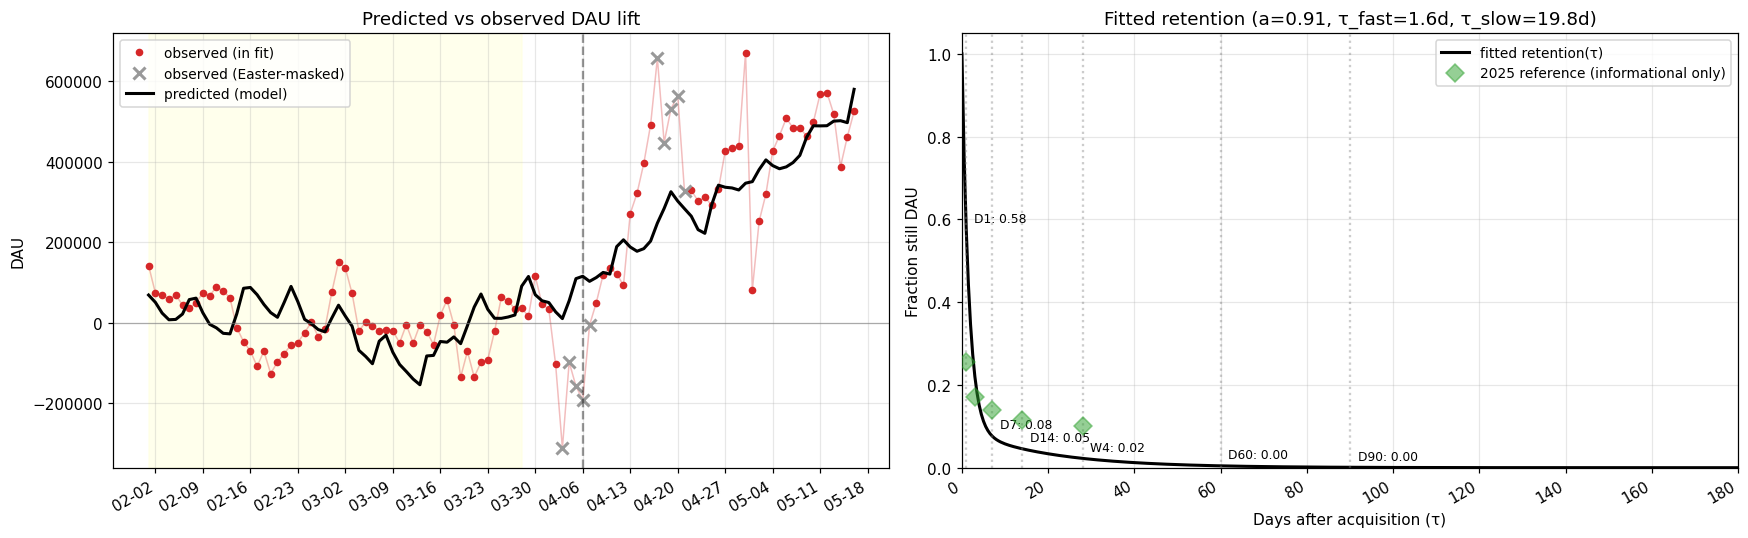

In [40]:
# [plot-retention-fit]
fig, (ax_fit, ax_curve) = plt.subplots(1, 2, figsize=(16, 5))

# Left: predicted vs observed DAU lift
masked_in_idx = common_index.isin(EASTER_MASK_DATES)
ax_fit.plot(common_index, dau_series.values, '-', linewidth=1.0, color=DAU_COLOR, alpha=0.3)
ax_fit.plot(common_index[~masked_in_idx], dau_series.values[~masked_in_idx],
            'o', markersize=4, color=DAU_COLOR, label='observed (in fit)')
ax_fit.plot(common_index[masked_in_idx], dau_series.values[masked_in_idx],
            'x', markersize=8, color=MASKED_COLOR, markeredgewidth=2, label='observed (Easter-masked)')
ax_fit.plot(common_index, predicted_DAU_lift.values, '-', linewidth=2, color='black', label='predicted (model)')
ax_fit.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
ax_fit.axvspan(BASELINE_START, BASELINE_END, color=BASELINE_BAND_COLOR, alpha=0.6)
ax_fit.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4)
ax_fit.set_title('Predicted vs observed DAU lift')
ax_fit.set_ylabel('DAU')
ax_fit.legend(fontsize=9, loc='upper left')
ax_fit.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax_fit.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# Right: fitted retention curve, with historical reference overlaid (NOT in loss)
tau_grid = np.linspace(0, 180, 361)
retention_grid = retention(tau_grid, fitted_a, fitted_tau_fast, fitted_tau_slow)
ax_curve.plot(tau_grid, retention_grid, '-', linewidth=2, color='black', label='fitted retention(τ)')
ref_lags = np.array(list(HISTORICAL_RETENTION_REFERENCE.keys()))
ref_vals = np.array(list(HISTORICAL_RETENTION_REFERENCE.values()))
ax_curve.plot(ref_lags, ref_vals, 'D', markersize=8, color='C2', alpha=0.5,
              label='2025 reference (informational only)', zorder=5)
for tau_marker, label in [(1, 'D1'), (7, 'D7'), (14, 'D14'), (28, 'W4'), (60, 'D60'), (90, 'D90')]:
    val = retention(tau_marker, fitted_a, fitted_tau_fast, fitted_tau_slow)
    ax_curve.axvline(tau_marker, color='grey', linestyle=':', alpha=0.4)
    ax_curve.annotate(f'{label}: {val:.2f}', xy=(tau_marker, val), xytext=(5, 5),
                      textcoords='offset points', fontsize=8)
ax_curve.set_xlabel('Days after acquisition (τ)')
ax_curve.set_ylabel('Fraction still DAU')
ax_curve.set_xlim(0, 180)
ax_curve.set_ylim(0, 1.05)
ax_curve.set_title(f'Fitted retention (a={fitted_a:.2f}, τ_fast={fitted_tau_fast:.1f}d, τ_slow={fitted_tau_slow:.1f}d)')
ax_curve.legend(fontsize=9)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [46]:
# [holdout-fit]
# Out-of-sample validation: refit using only training-window data, then
# predict the holdout window. If holdout RMSE is comparable to training RMSE,
# the model generalizes. If holdout is much worse, the fit is overfit or the
# underlying dynamics aren't stationary across the window.
HOLDOUT_START = pd.Timestamp('2026-05-01')

holdout_train_mask = fit_mask & (common_index < HOLDOUT_START)
holdout_test_mask = fit_mask & (common_index >= HOLDOUT_START)
post_train_mask = (common_index >= CAMPAIGN_LAUNCH) & holdout_train_mask

# Recompute empirical integrated retention using ONLY training data —
# avoids leaking holdout info via the integral constraint.
holdout_target_integrated = (
    dau_series.values[post_train_mask].sum() /
    np_series.values[post_train_mask].sum()
)


def holdout_loss(params):
    a, tau_fast, tau_slow = params

    predicted = predict_dau_lift(np_series.values, *params)
    conv_residuals = (predicted - dau_series.values)[holdout_train_mask]
    conv_term = np.mean(conv_residuals ** 2) / (DAU_LIFT_SCALE ** 2)

    floor_violation = max(0.0, TAU_SLOW_FLOOR - tau_slow)
    reg_term = REG_WEIGHT * floor_violation ** 2

    integral_residual = integrated_retention(a, tau_fast, tau_slow) - holdout_target_integrated
    integral_term = INTEGRAL_WEIGHT * integral_residual ** 2

    d1_residual = retention(1.0, a, tau_fast, tau_slow) - SHAPE_ANCHOR_D1
    shape_term = SHAPE_ANCHOR_WEIGHT * d1_residual ** 2

    return conv_term + reg_term + integral_term + shape_term


holdout_fit_result = minimize(holdout_loss, INITIAL_PARAMS, bounds=BOUNDS, method='L-BFGS-B')
holdout_predicted = predict_dau_lift(np_series.values, *holdout_fit_result.x)

# RMSEs
train_resid = (holdout_predicted - dau_series.values)[holdout_train_mask]
test_resid  = (holdout_predicted - dau_series.values)[holdout_test_mask]
train_rmse = np.sqrt(np.mean(train_resid ** 2))
test_rmse  = np.sqrt(np.mean(test_resid ** 2))
# Also: the bias (mean signed residual) to detect systematic over/under prediction
train_bias = train_resid.mean()
test_bias  = test_resid.mean()

# Reference: same RMSEs from the FULL fit (which had access to all data)
full_train_resid = (predicted_DAU_lift.values - dau_series.values)[holdout_train_mask]
full_test_resid  = (predicted_DAU_lift.values - dau_series.values)[holdout_test_mask]
full_train_rmse  = np.sqrt(np.mean(full_train_resid ** 2))
full_test_rmse   = np.sqrt(np.mean(full_test_resid ** 2))

print(f'Holdout split: train ends {(HOLDOUT_START - pd.Timedelta(days=1)).strftime("%Y-%m-%d")}, '
      f'test starts {HOLDOUT_START.strftime("%Y-%m-%d")}')
print(f'  Train fit-days: {int(holdout_train_mask.sum())} '
      f'(post-campaign: {int(post_train_mask.sum())})')
print(f'  Test fit-days:  {int(holdout_test_mask.sum())}  (all post-campaign)')
print()
print(f'Holdout-fit parameters:')
print(f'  a={holdout_fit_result.x[0]:.3f}, τ_fast={holdout_fit_result.x[1]:.2f}d, τ_slow={holdout_fit_result.x[2]:.2f}d')
print(f'  Integrated retention: model={integrated_retention(*holdout_fit_result.x):.3f}, '
      f'train-empirical target={holdout_target_integrated:.3f}')
print()
print(f'RMSE / bias comparison (DAU/day):')
print(f'              {"Train (in-sample)":>22}    {"Holdout (out-of-sample)":>25}')
print(f'  Holdout fit:    RMSE={train_rmse:>8,.0f}, bias={train_bias:>+8,.0f}    RMSE={test_rmse:>8,.0f}, bias={test_bias:>+8,.0f}')
print(f'  Full fit:       RMSE={full_train_rmse:>8,.0f}, bias={full_train_resid.mean():>+8,.0f}    '
      f'RMSE={full_test_rmse:>8,.0f}, bias={full_test_resid.mean():>+8,.0f}')
print()
print(f'Interpretation:')
print(f'  - Holdout-fit train RMSE ≈ Holdout-fit test RMSE  → model generalizes within window')
print(f'  - Holdout test RMSE >> train RMSE                  → model overfits or dynamics drift')
print(f'  - |test bias| >> train bias                        → systematic miss in holdout')


Holdout split: train ends 2026-04-30, test starts 2026-05-01
  Train fit-days: 79 (post-campaign: 18)
  Test fit-days:  16  (all post-campaign)

Holdout-fit parameters:
  a=0.935, τ_fast=1.98d, τ_slow=28.86d
  Integrated retention: model=3.727, train-empirical target=3.724

RMSE / bias comparison (DAU/day):
                   Train (in-sample)      Holdout (out-of-sample)
  Holdout fit:    RMSE= 100,331, bias= -12,718    RMSE= 104,265, bias= +30,609
  Full fit:       RMSE= 101,499, bias= -23,522    RMSE= 104,033, bias= -25,229

Interpretation:
  - Holdout-fit train RMSE ≈ Holdout-fit test RMSE  → model generalizes within window
  - Holdout test RMSE >> train RMSE                  → model overfits or dynamics drift
  - |test bias| >> train bias                        → systematic miss in holdout


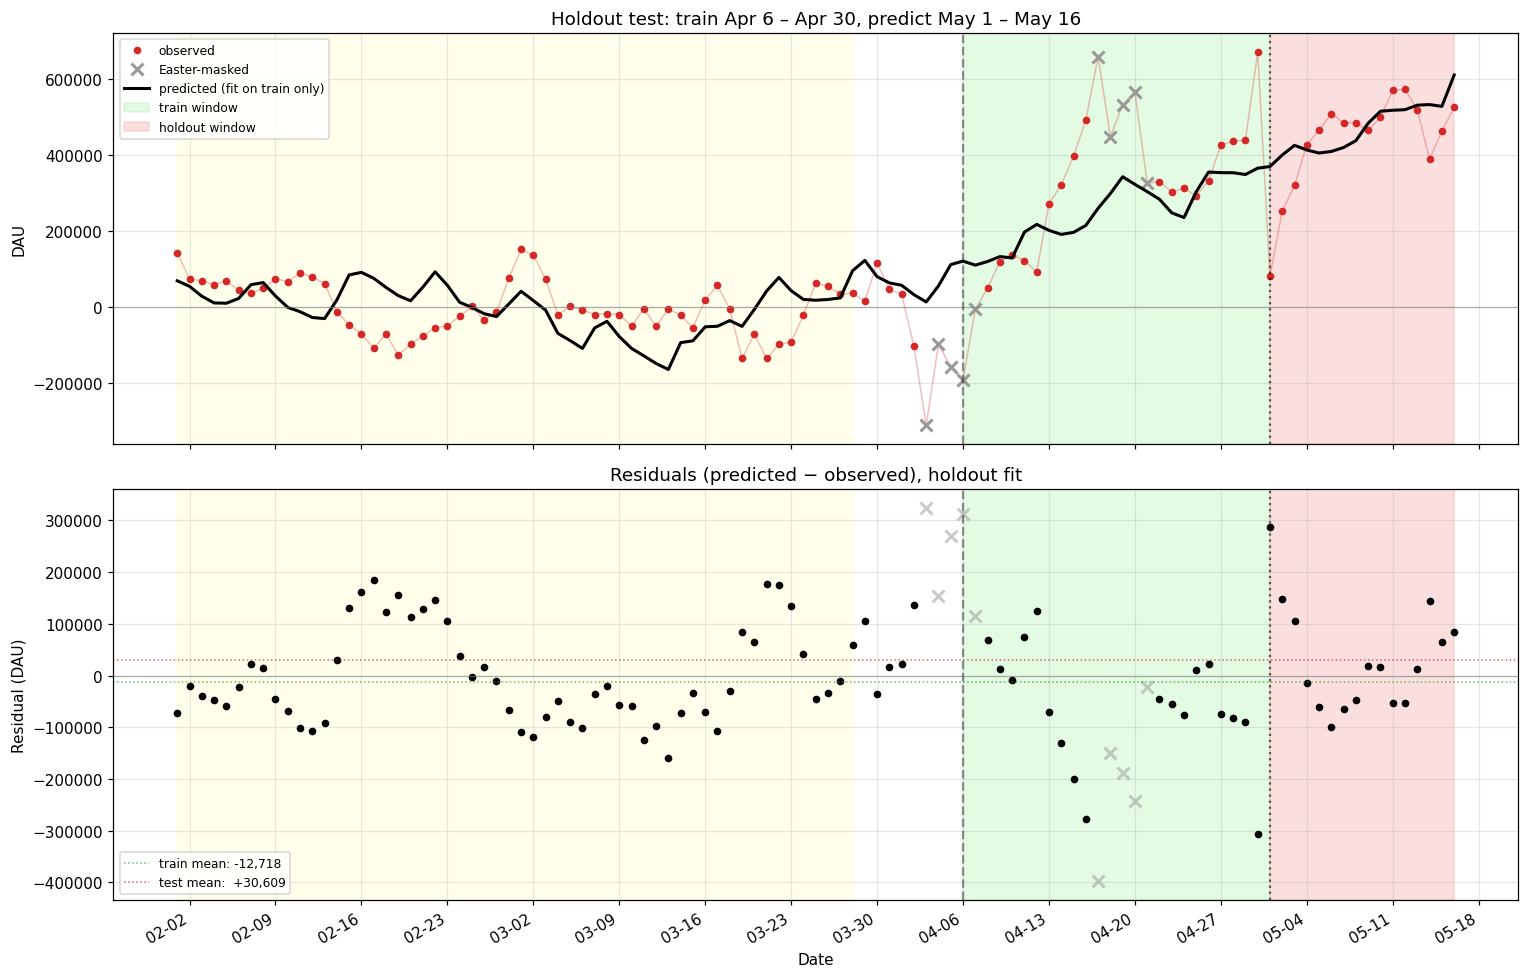

In [47]:
# [plot-holdout]
fig, (ax_fit, ax_resid) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

masked_in_idx = common_index.isin(EASTER_MASK_DATES)

# Top: predicted vs observed, with train/test windows shaded
ax_fit.plot(common_index, dau_series.values, '-', linewidth=1.0, color=DAU_COLOR, alpha=0.3)
ax_fit.plot(common_index[~masked_in_idx], dau_series.values[~masked_in_idx],
            'o', markersize=4, color=DAU_COLOR, label='observed')
ax_fit.plot(common_index[masked_in_idx], dau_series.values[masked_in_idx],
            'x', markersize=8, color=MASKED_COLOR, markeredgewidth=2, label='Easter-masked')
ax_fit.plot(common_index, holdout_predicted, '-', linewidth=2, color='black',
            label=f'predicted (fit on train only)')
ax_fit.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
ax_fit.axvspan(BASELINE_START, BASELINE_END, color=BASELINE_BAND_COLOR, alpha=0.6)
ax_fit.axvspan(CAMPAIGN_LAUNCH, HOLDOUT_START, color='lightgreen', alpha=0.25, label='train window')
ax_fit.axvspan(HOLDOUT_START, common_index.max(), color='lightcoral', alpha=0.25, label='holdout window')
ax_fit.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4)
ax_fit.axvline(HOLDOUT_START, color='black', linestyle=':', alpha=0.6)
ax_fit.set_title(f'Holdout test: train Apr 6 – Apr 30, predict May 1 – May 16')
ax_fit.set_ylabel('DAU')
ax_fit.legend(fontsize=8, loc='upper left')

# Bottom: residuals (predicted - observed) for the holdout fit
residuals = holdout_predicted - dau_series.values
ax_resid.plot(common_index[~masked_in_idx], residuals[~masked_in_idx],
              'o', markersize=4, color='black')
ax_resid.plot(common_index[masked_in_idx], residuals[masked_in_idx],
              'x', markersize=8, color=MASKED_COLOR, markeredgewidth=2, alpha=0.5)
ax_resid.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
ax_resid.axhline(train_bias, color='C2', linewidth=1, linestyle=':', alpha=0.7,
                 label=f'train mean: {train_bias:+,.0f}')
ax_resid.axhline(test_bias, color='C3', linewidth=1, linestyle=':', alpha=0.7,
                 label=f'test mean:  {test_bias:+,.0f}')
ax_resid.axvspan(BASELINE_START, BASELINE_END, color=BASELINE_BAND_COLOR, alpha=0.6)
ax_resid.axvspan(CAMPAIGN_LAUNCH, HOLDOUT_START, color='lightgreen', alpha=0.25)
ax_resid.axvspan(HOLDOUT_START, common_index.max(), color='lightcoral', alpha=0.25)
ax_resid.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4)
ax_resid.axvline(HOLDOUT_START, color='black', linestyle=':', alpha=0.6)
ax_resid.set_title('Residuals (predicted − observed), holdout fit')
ax_resid.set_ylabel('Residual (DAU)')
ax_resid.set_xlabel('Date')
ax_resid.legend(fontsize=8, loc='lower left')
ax_resid.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax_resid.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [ ]:
# [save-fit]
# Persist the fitted retention parameters so 03_forecast_projection can use
# them without re-running the fit.
import json

retention_fit_metadata = {
    'a':                       float(fitted_a),
    'tau_fast':                float(fitted_tau_fast),
    'tau_slow':                float(fitted_tau_slow),
    'integrated_retention':    float(integrated_retention(*fit_result.x)),
    'target_integrated':       float(TARGET_INTEGRATED_RETENTION),
    'in_sample_rmse_excl_easter': float(conv_rmse_final),
    'fit_window_start':        BASELINE_START.strftime('%Y-%m-%d'),
    'fit_window_end':          common_index.max().strftime('%Y-%m-%d'),
    'campaign_launch':         CAMPAIGN_LAUNCH.strftime('%Y-%m-%d'),
    'baseline_window':         [BASELINE_START.strftime('%Y-%m-%d'),
                                BASELINE_END.strftime('%Y-%m-%d')],
    'loss_weights': {
        'reg_weight':          REG_WEIGHT,
        'tau_slow_floor':      TAU_SLOW_FLOOR,
        'integral_weight':     INTEGRAL_WEIGHT,
        'shape_anchor_weight': SHAPE_ANCHOR_WEIGHT,
        'shape_anchor_d1':     SHAPE_ANCHOR_D1,
    },
    'easter_mask_dates':       [d.strftime('%Y-%m-%d') for d in EASTER_MASK_DATES],
}

OUT_PATH = DATA_DIR / 'retention_fit.json'
with open(OUT_PATH, 'w') as f:
    json.dump(retention_fit_metadata, f, indent=2)

print(f'Wrote fit metadata → {OUT_PATH.resolve()}')
print(json.dumps(retention_fit_metadata, indent=2))
